/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_91141/3985681321.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final = pd.concat([process_file(f"csv_log/P{i}_baseline.csv", f"P{i}") for i in range(1,13)])


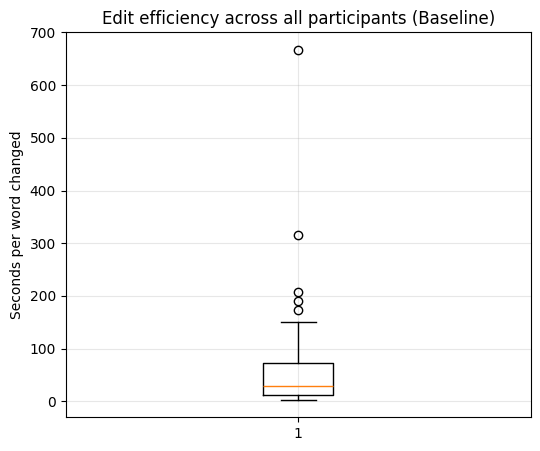

count     88.000000
unique    85.000000
top        3.428571
freq       2.000000
Name: sec_per_word, dtype: float64
평균: 56.48253143777288
중앙값: 30.055555555555557
표준편차: 85.88542569901041
최솟값: 3.0
최댓값: 667.0


In [6]:
import pandas as pd, ast
from difflib import ndiff
import matplotlib.pyplot as plt

def process_file(path, pid):
    df = pd.read_csv(path)
    df["details"] = df["details"].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else {})
    df["iid"] = df.apply(lambda r: r["details"].get("instanceId") if "add.instance" in r["event"] else r["details"].get("nodeId"), axis=1)
    df["ts"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S")

    recs, prev_label, prev_t = [], {}, {}
    for _, row in df[df["iid"].notnull()].sort_values("ts").iterrows():
        iid, ev, det, t = row["iid"], row["event"], row["details"], row["ts"]
        if "add.instance" in ev: 
            prev_label[iid], prev_t[iid] = det.get("instanceLabel"), t
        if "edit" in ev and iid in prev_label:
            new, old = det.get("newLabel"), prev_label[iid]
            diff = [d for d in ndiff(old.split(), new.split()) if d[0] in "+-"]
            recs.append([(t-prev_t[iid]).total_seconds(), len(diff)])
            prev_label[iid], prev_t[iid] = new, t
    return pd.DataFrame(recs, columns=["duration_sec","words_changed"])

# ---- 전체 참가자 처리 ----
final = pd.concat([process_file(f"csv_log/P{i}_baseline.csv", f"P{i}") for i in range(1,13)])

# ---- 단어당 소요 시간 ----
final["sec_per_word"] = final["duration_sec"] / final["words_changed"]

# ---- Boxplot ----
plt.figure(figsize=(6,5))
plt.boxplot(final["sec_per_word"].dropna())
plt.ylabel("Seconds per word changed")
plt.title("Edit efficiency across all participants (Baseline)")
plt.grid(alpha=0.3)
plt.show()

# ---- 통계값 출력 ----
desc = final["sec_per_word"].describe(percentiles=[.25, .5, .75])
print(desc)

print("평균:", final["sec_per_word"].mean())
print("중앙값:", final["sec_per_word"].median())
print("표준편차:", final["sec_per_word"].std())
print("최솟값:", final["sec_per_word"].min())
print("최댓값:", final["sec_per_word"].max())


/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_91141/1414234075.py:58: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  baseline_all = pd.concat([process_baseline(f"csv_log/P{i}_baseline.csv", f"P{i}") for i in range(1,13)])


<Figure size 700x500 with 0 Axes>

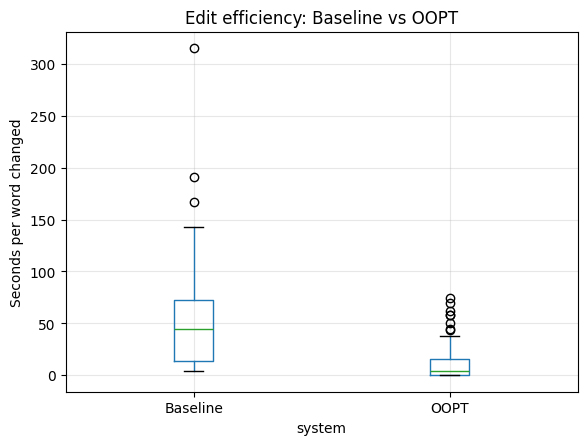

          count       mean        std  min        25%    50%     75%    max
system                                                                     
Baseline   47.0  59.134090  60.456341  4.5  13.693182  44.75  72.625  315.0
OOPT      130.0  10.746154  15.353868  0.0   0.000000   4.00  15.500   74.0


In [11]:
import pandas as pd, ast, matplotlib.pyplot as plt

# -------------------------
# Baseline (이전 버전 그대로 사용)
# -------------------------
def process_baseline(path, pid):
    df = pd.read_csv(path)
    df["details"] = df["details"].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else {})
    df["ts"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S")

    edits = df[df["event"]=="baselineboard.node.edit"].copy().sort_values("ts")
    recs = []
    prev_text, prev_time = {}, {}

    for _, row in edits.iterrows():
        det = row["details"]
        node = det.get("nodeId")
        new_text = det.get("newLabel")
        t = row["ts"]

        if node in prev_text:
            old = prev_text[node]
            diff = sum(1 for d in (set(old.split()) ^ set(new_text.split())))
            wc = diff if diff > 0 else 1
            dur = (t - prev_time[node]).total_seconds()
            recs.append([pid, node, dur, wc, dur/wc])

        prev_text[node] = new_text
        prev_time[node] = t

    return pd.DataFrame(recs, columns="pid nodeId duration_sec words_changed sec_per_word".split())


# -------------------------
# OOPT (항상 word=1, 직전 이벤트와 차이)
# -------------------------
def process_oopt(path, pid):
    df = pd.read_csv(path)
    df["details"] = df["details"].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else {})
    df["ts"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S")

    edits = df[df["event"]=="object_node.edit.saved"].copy().sort_values("ts")
    recs = []

    for i, row in edits.iterrows():
        if i-1 in df.index:
            dur = (row["ts"] - df.loc[i-1, "ts"]).total_seconds()
        else:
            dur = None
        recs.append([pid, row["details"].get("nodeId"), dur, 1, dur])

    return pd.DataFrame(recs, columns="pid nodeId duration_sec words_changed sec_per_word".split())


# -------------------------
# 모든 참가자 합치기
# -------------------------
baseline_all = pd.concat([process_baseline(f"csv_log/P{i}_baseline.csv", f"P{i}") for i in range(1,13)])
oopt_all     = pd.concat([process_oopt(f"csv_log/P{i}_OOPT.csv", f"P{i}") for i in range(1,13)])

baseline_all["system"] = "Baseline"
oopt_all["system"] = "OOPT"

final = pd.concat([baseline_all, oopt_all])

# -------------------------
# Boxplot 비교
# -------------------------
plt.figure(figsize=(7,5))
final.boxplot(column="sec_per_word", by="system")
plt.suptitle("")
plt.ylabel("Seconds per word changed")
plt.title("Edit efficiency: Baseline vs OOPT")
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# 통계값 비교
# -------------------------
stats = final.groupby("system")["sec_per_word"].describe()
print(stats)


In [12]:
from scipy.stats import ttest_rel

# 참가자별 평균값
baseline_avg = baseline_all.groupby("pid")["sec_per_word"].mean()
oopt_avg = oopt_all.groupby("pid")["sec_per_word"].mean()

# 두 시리즈를 participant ID 기준으로 align
df_ttest = pd.DataFrame({
    "baseline": baseline_avg,
    "oopt": oopt_avg
}).dropna()

# paired t-test
t_stat, p_val = ttest_rel(df_ttest["baseline"], df_ttest["oopt"])
print("Paired t-test 결과")
print("t =", t_stat, "p =", p_val)


Paired t-test 결과
t = 2.4586462363370534 p = 0.03940184966827597


In [21]:
import pandas as pd, ast, re
from difflib import ndiff

# ----------------------------
# 1) 텍스트 블록 파싱
# ----------------------------
with open("P1_text_edits.txt", "r") as f:
    raw_text = f.read()

blocks = re.split(r"(?=New description:)", raw_text)
records = []
for block in blocks:
    prev_match = re.search(r"Previous description:\s*\"(.*?)\"", block, re.S)
    new_match  = re.search(r"New description:\s*\"(.*?)\"", block, re.S)
    if new_match:
        prev_desc = prev_match.group(1) if prev_match else None
        new_desc  = new_match.group(1)
        records.append({"previous_description": prev_desc, "new_description": new_desc})

df_text = pd.DataFrame(records)

# ----------------------------
# 2) CSV에서 duration 계산
# ----------------------------
df = pd.read_csv("csv_log/P1_OOPT.csv")
df["ts"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S")

durations = []
for idx, row in df.iterrows():
    if row["event"] == "api.generate_text_to_graph.succeeded":
        if idx-1 in df.index:
            prev_time = df.loc[idx-1, "ts"]
            durations.append((row["ts"] - prev_time).total_seconds())

df_durations = pd.DataFrame({"duration_sec": durations})

# ----------------------------
# 3) 합치고 조건 필터링
# ----------------------------
df_final = pd.concat([df_text, df_durations], axis=1)

# 단어 diff 계산
def count_changed_words(old, new):
    if not old or not new:
        return 0
    diff = [d for d in ndiff(old.split(), new.split()) if d[0] in "+-"]
    return len(diff)

df_final["words_changed"] = df_final.apply(
    lambda r: count_changed_words(r["previous_description"], r["new_description"]),
    axis=1
)

# 제외 규칙 적용
df_final = df_final.dropna(subset=["previous_description"])
df_final = df_final[df_final["words_changed"] > 0].copy()

# sec_per_word 계산
df_final["sec_per_word"] = df_final["duration_sec"] / df_final["words_changed"]

print(df_final.head())
print(df_final.describe())

# 저장
# df_final.to_csv("P1_text_edits_with_duration_filtered.csv", index=False)


                                 previous_description  \
3   A dark, slightly tanned male is wearing a shor...   
9   A dark brown, slightly tanned male with short,...   
11  A woman with dark brown, slightly tanned skin ...   
12  A dark brown, slightly tanned male with short,...   
13  A woman with dark brown, slightly tanned skin ...   

                                      new_description  duration_sec  \
3   A woman with dark brown hair and a slightly ta...          97.0   
9    an elderly man with white hair and a broad smile           1.0   
11  A dark brown, slightly tanned male with short,...          12.0   
12  A woman with dark brown, slightly tanned skin ...          11.0   
13  A dark brown, slightly tanned male with short,...          29.0   

    words_changed  sec_per_word  
3              34      2.852941  
9              25      0.040000  
11             29      0.413793  
12             27      0.407407  
13             29      1.000000  
       duration_sec  words